### Imports and Configuration

In [59]:
import os
import numpy as np
import pandas as pd
import warnings
from scipy.stats import linregress
import matplotlib.pyplot as plt
from pathlib import Path
warnings.filterwarnings('ignore')


### Paths

In [3]:
import pandas as pd

df = pd.read_csv("../../data/rawdata/uhn_breast/omics/cnv_hugo.tsv", sep="\t", index_col=0)

In [5]:
# index is ABL2, column name is REF010, print out value
print(df.loc['ABL2', 'REF010'])

6.0


### McGill results

In [61]:
# Load model order
order_df = pd.read_csv(mcgill_model_order_path, sep='\t', header=None, names=['Index', 'model_id'])
order_df = order_df.sort_values('Index') # Ensure we follow the 0, 1, 2... sequence

# Load Folds and build the results DataFrame
fold_data = {}
for i in range(1, 6):
    file_path = os.path.join(mcgill_result_dir, f"fold{i}.txt")
    # NeST-VNN usually outputs a single column of floats
    fold_data[f'fold{i}'] = pd.read_csv(file_path, header=None)[0]

results_df = pd.DataFrame(fold_data)

# Add the ModelID and calculate Average
results_df.insert(0, 'model_id', order_df['model_id'].values)
results_df['average'] = results_df[[f'fold{i}' for i in range(1, 6)]].mean(axis=1)

# Merge with Metadata
meta_df = pd.read_csv(mcgill_model_meta_path, sep='\t')

# Ensure the join key matches (adjust 'ModelID' to match your meta column name)
final_df = pd.merge(results_df, meta_df, on='model_id', how='left')

final_df.to_csv("../data/procdata/3_carboplatin/McGill_cis_nest_vnn_results.txt", index=False)


### UHN complete cohort results

In [62]:
# Load model order
order_df = pd.read_csv(uhn_complete_model_order_path, sep='\t', header=None, names=['Index', 'model.id'])
order_df = order_df.sort_values('Index') # Ensure we follow the 0, 1, 2... sequence

# Load Folds and build the results DataFrame
fold_data = {}
for i in range(1, 6):
    file_path = os.path.join(uhn_complete_dir, f"fold{i}.txt")
    # NeST-VNN usually outputs a single column of floats
    fold_data[f'fold{i}'] = pd.read_csv(file_path, header=None)[0]

results_df = pd.DataFrame(fold_data)

# Add the ModelID and calculate Average
results_df.insert(0, 'model.id', order_df['model.id'].values)
results_df['average'] = results_df[[f'fold{i}' for i in range(1, 6)]].mean(axis=1)

# Merge with Metadata
meta_df = pd.read_csv(uhn_model_meta_path, index_col=0)
final_df = pd.merge(results_df, meta_df, on='model.id', how='left')

final_df.to_csv("../data/procdata/3_carboplatin/UHN_cis_complete_nest_vnn_results.txt", index=False)

### UHN strict cohort results

In [63]:
# Load model order
order_df = pd.read_csv(uhn_strict_model_order_path, sep='\t', header=None, names=['Index', 'model.id'])
order_df = order_df.sort_values('Index') # Ensure we follow the 0, 1, 2... sequence

# Load Folds and build the results DataFrame
fold_data = {}
for i in range(1, 6):
    file_path = os.path.join(uhn_strict_dir, f"fold{i}.txt")
    # NeST-VNN usually outputs a single column of floats
    fold_data[f'fold{i}'] = pd.read_csv(file_path, header=None)[0]

results_df = pd.DataFrame(fold_data)

# Add the ModelID and calculate Average
results_df.insert(0, 'model.id', order_df['model.id'].values)
results_df['average'] = results_df[[f'fold{i}' for i in range(1, 6)]].mean(axis=1)

# Merge with Metadata
meta_df = pd.read_csv(uhn_model_meta_path, index_col=0)
final_df = pd.merge(results_df, meta_df, on='model.id', how='left')

final_df.to_csv("../data/procdata/3_carboplatin/UHN_cis_strict_nest_vnn_results.txt", index=False)

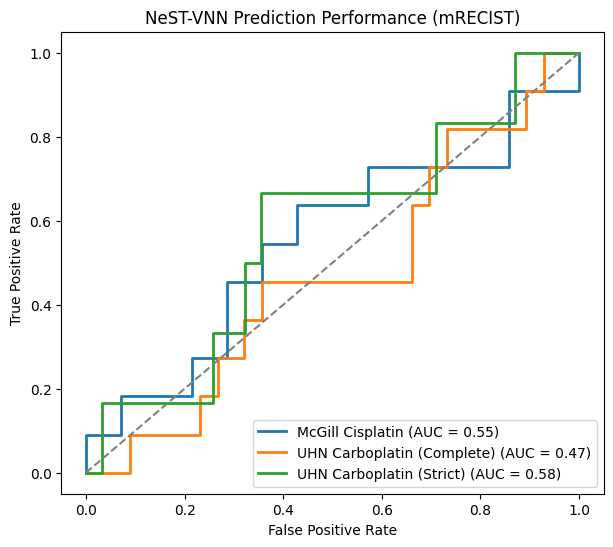

In [64]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def calculate_auc(df, mrecist_col, pred_col='average'):
    # Define Responders (CR, PR) vs Non-Responders (SD, PD)
    # Ensure we handle potential whitespace or case sensitivity
    df = df.copy()
    df[mrecist_col] = df[mrecist_col].str.upper().str.strip()
    
    # Map to binary
    binary_map = {'CR': 1, 'PR': 1, 'SD': 0, 'PD': 0}
    df['target'] = df[mrecist_col].map(binary_map)
    
    # Drop samples that don't have a valid mRECIST label
    df = df.dropna(subset=['target'])
    
    auc = roc_auc_score(df['target'], df[pred_col])
    fpr, tpr, _ = roc_curve(df['target'], df[pred_col])
    return auc, fpr, tpr

# Load your processed files
mcgill = pd.read_csv("../data/procdata/3_carboplatin/McGill_cis_nest_vnn_results.txt")
uhn_comp = pd.read_csv("../data/procdata/3_carboplatin/UHN_cis_complete_nest_vnn_results.txt")
uhn_strict = pd.read_csv("../data/procdata/3_carboplatin/UHN_cis_strict_nest_vnn_results.txt")

datasets = [
    (mcgill, 'mRECIST.treatment', 'McGill Cisplatin'),
    (uhn_comp, 'mRECIST', 'UHN Carboplatin (Complete)'),
    (uhn_strict, 'mRECIST', 'UHN Carboplatin (Strict)')
]

plt.figure(figsize=(7, 6))
for df, col, name in datasets:
    auc_val, fpr, tpr = calculate_auc(df, col)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {auc_val:.2f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--')
plt.title('NeST-VNN Prediction Performance (mRECIST)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend(loc="lower right")
plt.show()

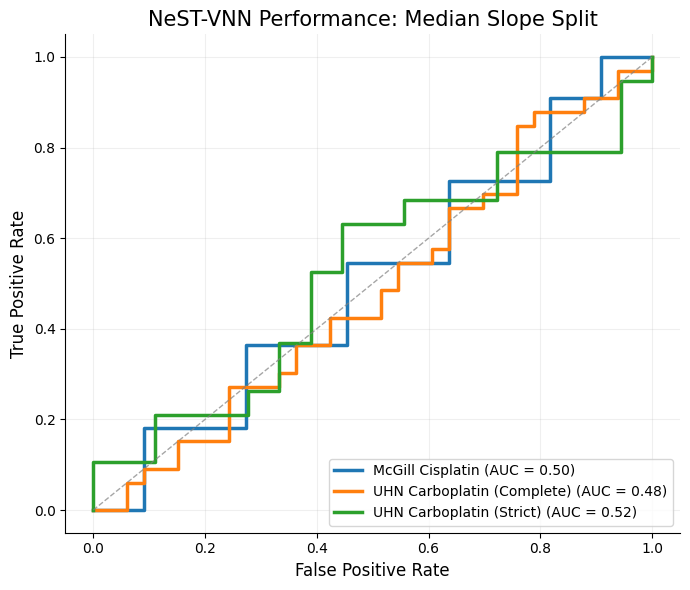

In [66]:
import pandas as pd
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt

def calculate_auc_by_slope(df, slope_col, pred_col='average'):
    """
    Binarizes the ground truth based on a median split of the slope values.
    Top 1/2 (>= median) = Responders (1)
    Bottom 1/2 (< median) = Non-Responders (0)
    """
    # 1. Clean data: drop rows missing the slope or prediction
    df = df.dropna(subset=[slope_col, pred_col]).copy()
    
    # 2. Determine the median threshold
    median_val = df[slope_col].median()
    
    # 3. Create binary target based on your instruction: Top 1/2 = Responders
    # Note: Biologically, check if a higher slope means a BETTER response in your data.
    # If higher slope means faster growth (Resistance), the AUC may appear below 0.5.
    df['target'] = (df[slope_col] >= median_val).astype(int)
    
    # 4. Calculate metrics
    auc_val = roc_auc_score(df['target'], df[pred_col])
    fpr, tpr, _ = roc_curve(df['target'], df[pred_col])
    return auc_val, fpr, tpr

# Load your processed files
mcgill = pd.read_csv("../data/procdata/3_carboplatin/McGill_cis_nest_vnn_results.txt")
uhn_comp = pd.read_csv("../data/procdata/3_carboplatin/UHN_cis_complete_nest_vnn_results.txt")
uhn_strict = pd.read_csv("../data/procdata/3_carboplatin/UHN_cis_strict_nest_vnn_results.txt")

# Update dataset list to use 'slopetr' for all
datasets = [
    (mcgill, 'TGI', 'McGill Cisplatin'),
    (uhn_comp, 'TGI', 'UHN Carboplatin (Complete)'),
    (uhn_strict, 'TGI', 'UHN Carboplatin (Strict)')
]

plt.figure(figsize=(7, 6))
for df, col, name in datasets:
    try:
        auc_val, fpr, tpr = calculate_auc_by_slope(df, col)
        plt.plot(fpr, tpr, lw=2.5, label=f'{name} (AUC = {auc_val:.2f})')
    except Exception as e:
        print(f"Error processing {name}: {e}")

# Formatting for a high-quality manuscript
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--', alpha=0.7)
plt.title('NeST-VNN Performance: Median Slope Split', fontsize=15)
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(alpha=0.2)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

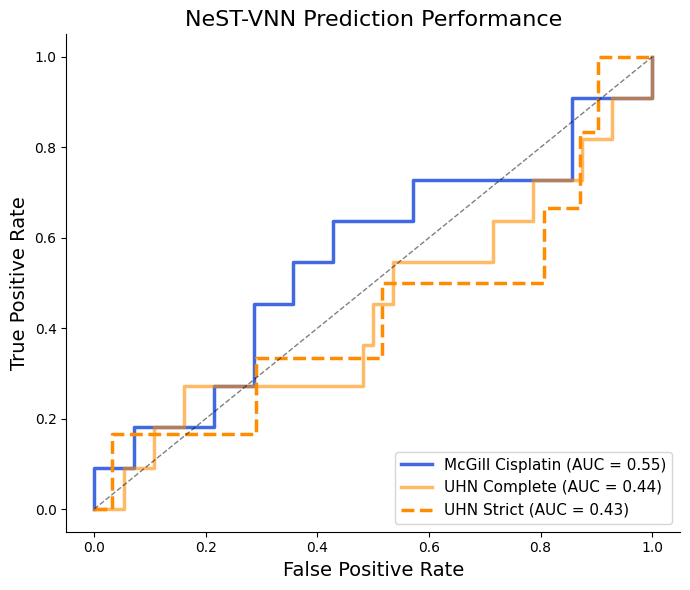

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Load your newly created files
mcgill = pd.read_csv("../data/procdata/3_carboplatin/McGill_cis_nest_vnn_results.txt")
uhn_comp = pd.read_csv("../data/procdata/3_carboplatin/UHN_cis_complete_nest_vnn_results.txt")
uhn_strict = pd.read_csv("../data/procdata/3_carboplatin/UHN_cis_strict_nest_vnn_results.txt")

def get_roc_metrics(df, mrecist_col):
    # Standardize mRECIST and filter
    df = df.dropna(subset=[mrecist_col])
    # Mapping CR/PR to 1, SD/PD to 0
    target = df[mrecist_col].isin(['CR', 'PR', 'cr', 'pr']).astype(int)
    # Use 'average' as it is your ensemble prediction column
    fpr, tpr, _ = roc_curve(target, df['average'])
    return fpr, tpr, auc(fpr, tpr)

# Calculate for all three
fpr_mg, tpr_mg, auc_mg = get_roc_metrics(mcgill, 'mRECIST.treatment')
fpr_comp, tpr_comp, auc_comp = get_roc_metrics(uhn_comp, 'mRECIST')
fpr_strict, tpr_strict, auc_strict = get_roc_metrics(uhn_strict, 'mRECIST')

# 2. Plotting (Panel F Style)
plt.figure(figsize=(7, 6))

plt.plot(fpr_mg, tpr_mg, color='royalblue', lw=2.5, 
         label=f'McGill Cisplatin (AUC = {auc_mg:.2f})')
plt.plot(fpr_comp, tpr_comp, color='darkorange', lw=2.5, alpha=0.6,
         label=f'UHN Complete (AUC = {auc_comp:.2f})')
plt.plot(fpr_strict, tpr_strict, color='darkorange', lw=2.5, linestyle='--',
         label=f'UHN Strict (AUC = {auc_strict:.2f})')

plt.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--', alpha=0.5)

# Formatting
plt.xlabel('False Positive Rate', fontsize=14)
plt.ylabel('True Positive Rate', fontsize=14)
plt.title('NeST-VNN Prediction Performance', fontsize=16)
plt.legend(loc="lower right", fontsize=11)
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

In [ ]:
fold1 = mcgill_result_dir "/" "fold1.txt"
fold2 = mcgill_result_dir "/" "fold2.txt"
...
fold5
create a dataframe each fold is a column, and last column is average
merge with metadata, make sure the order of the model is the same as model_order files

,S108099,REF020,S45086,S71208,S100534,S53782,REF022,REF032,REF061,REF048,...,S100804,REF043.2,REF043.3,REF063,S28077,REF057,REF030,S44441,S69196,S90189
hugo.id,,,,,,,,,,,,,,,,,,,,,
A1BG,4.0,4.0,1.0,3.0,3.0,1.0,1.0,3.0,4.0,1.0,...,NaN,4.0,5.0,NaN,3.0,NaN,3.0,NaN,1.0,1.0
A1BG-AS1,4.0,4.0,1.0,3.0,3.0,1.0,1.0,3.0,4.0,1.0,...,NaN,4.0,5.0,NaN,3.0,NaN,3.0,NaN,1.0,1.0
A1CF,3.0,NaN,6.0,4.0,NaN,3.0,NaN,4.0,NaN,NaN,...,NaN,0.0,0.0,NaN,5.0,NaN,3.0,3.0,NaN,3.0
A2M,4.0,3.0,3.0,NaN,5.0,3.0,3.0,1.0,NaN,NaN,...,NaN,0.0,1.0,3.0,5.0,NaN,5.0,NaN,3.0,1.0
A2M-AS1,4.0,3.0,3.0,NaN,5.0,3.0,3.0,1.0,NaN,NaN,...,NaN,0.0,1.0,3.0,5.0,NaN,5.0,NaN,3.0,1.0


In [27]:
car["model.id"]

0     INSB014
1     INSB019
2      REF001
3      REF002
4      REF003
       ...   
62     S72955
63     S73230
64     S73263
65     S73471
66     S85277
Name: model.id, Length: 67, dtype: object

In [4]:
# Load in gene file
gene_file = "../data/rawdata/nest_vnn/gene2ind.txt"

# Load in nesv_vnn genes
gene_map = pd.read_csv(gene_file, sep="\t", header=None)
gene_map.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/complete_cohort/gene2ind.txt", sep="\t", header=False, index=False)
gene_map.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/strict_cohort/gene2ind.txt", sep="\t", header=False, index=False)

gene_map.columns = ["index", "gene"]
gene_list = gene_map["gene"].tolist()
print("NEST_VNN Gene:", len(gene_list))

# Prepare mutation matrix
mut_bin = mut.map(lambda x: 0 if (pd.isna(x) or x == "0" or str(x).lower() == "silent") else 1)

mut_complete = mut_bin.loc[mut_bin.index.isin(gene_list), mut_bin.columns.isin(car["model.id"])]
print(f"Complete shape: {mut_complete.shape}")
mut_strict = mut_bin.loc[mut_bin.index.isin(gene_list), mut_bin.columns.isin(car_strict["model.id"])]
print(f"Strict shape: {mut_strict.shape}")

# Prepare CNV matrix
cnv_complete = cnv.loc[cnv.index.isin(gene_list), cnv.columns.isin(car["model.id"])]
print(f"Complete shape: {cnv_complete.shape}")
cnv_strict = cnv.loc[cnv.index.isin(gene_list), cnv.columns.isin(car_strict["model.id"])]
print(f"Strict shape: {cnv_strict.shape}")




NEST_VNN Gene: 718
Complete shape: (670, 67)
Strict shape: (670, 37)
Complete shape: (711, 67)
Strict shape: (711, 37)


### Complete dataset

In [5]:
# Prepare CNV matrices
cna = (cnv_complete == 0).astype(int)
cnd = (cnv_complete >= 7).astype(int)
cna = cna.reindex(gene_list).fillna(0)
cnd = cnd.reindex(gene_list).fillna(0)
mut_complete = mut_complete.reindex(gene_list).fillna(0)

# transpose
mut_complete = mut_complete.T
cna = cna.T
cnd = cnd.T

# convert to int
mut_complete = mut_complete.astype(int)
cna = cna.astype(int)
cnd = cnd.astype(int)

# Save NeST input files
mut_complete.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/complete_cohort/cell2mutation.txt", header=False, index=False)
cna.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/complete_cohort/cell2amplification.txt", header=False, index=False)
cnd.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/complete_cohort/cell2cndeletion.txt", header=False, index=False)

In [ ]:
print(mut_complete.shape)
print(cna.shape)

(67, 718)

In [43]:
test_df = pd.DataFrame({
    0: car["model.id"],
    1: ["CARBOPLATIN"] * len(car["model.id"])
})
test_df["AUC"] = 0
test_df["dataset"] = "PDX"

test_path = "../data/procdata/3_carboplatin/UHN_nest_input/complete_cohort/test_data.txt"
test_df.to_csv(test_path, sep="\t", header=False, index=False)

### Strict dataset 

In [7]:
# Prepare CNV matrices
cna = (cnv_strict == 0).astype(int)
cnd = (cnv_strict >= 7).astype(int)
cna = cna.reindex(gene_list).fillna(0)
cnd = cnd.reindex(gene_list).fillna(0)
mut_strict = mut_strict.reindex(gene_list).fillna(0)

# transpose
mut_strict = mut_strict.T
cna = cna.T
cnd = cnd.T

# convert to int
mut_strict = mut_strict.astype(int)
cna = cna.astype(int)
cnd = cnd.astype(int)

# Save NeST input files
mut_strict.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/strict_cohort/cell2mutation.txt", header=False, index=False)
cna.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/strict_cohort/cell2amplification.txt", header=False, index=False)
cnd.to_csv("../data/procdata/3_carboplatin/UHN_nest_input/strict_cohort/cell2cndeletion.txt", header=False, index=False)

In [44]:
test_df = pd.DataFrame({
    0: car_strict["model.id"],
    1: ["CARBOPLATIN"] * len(car_strict["model.id"])
})
test_df["AUC"] = 0
test_df["dataset"] = "PDX"

test_path = "../data/procdata/3_carboplatin/UHN_nest_input/strict_cohort/test_data.txt"
test_df.to_csv(test_path, sep="\t", header=False, index=False)

### Load response tabel

In [9]:
resp = pd.read_csv(response_file)

print("Total experiments:", resp.shape[0])

Total experiments: 128


### Parse model and drug


In [10]:
resp[["model_id", "drug"]] = resp["batch.name"].str.split(".", expand=True)

print("Unique drugs:", resp["drug"].unique())

Unique drugs: <StringArray>
['Cisplatin', 'Gemcitabine', 'Paclitaxel', 'Doxorubicin', 'Carboplatin']
Length: 5, dtype: str


### Filter cisplatin/carboplatin experiments

In [12]:
cis = resp[resp["drug"].str.lower() == "cisplatin"].copy()
car = resp[resp["drug"].str.lower() == "carboplatin"].copy()
print("Cisplatin experiments:", cis.shape[0])
print("Carboplatin experiments:", car.shape[0])

Cisplatin experiments: 30
Carboplatin experiments: 12


Carboplatin data is two low (n=12) for robust ML model testing. 

Will focuse on cisplatin for model testing.

### Extract unique models

In [13]:
models = sorted(cis["model_id"].unique())

print("Unique cisplatin models:", len(models))

models_df = pd.DataFrame({"model_id": models})

Unique cisplatin models: 30


### Extract omics map

In [15]:
omics = pd.read_csv(omicsmap)
omics = omics[omics["source"] == "PDX"]
omics = omics[omics["model.id"].str.lower().str.endswith("ci")]
omics["model_id"] = "GCRC" + omics["model.id"].str.split(".").str[2].str.replace("Ci", "", regex=False)
# collapse mDataType
omics = (
    omics
    .groupby(["model.id", "biobase.id", "source", "model_id"], as_index=False)
    .agg({"mDataType": lambda x: "/".join(sorted(x.unique()))})
)
omics = omics[omics["mDataType"].str.contains("CNV")].reset_index(inplace=False)

omics = omics[["model_id", "biobase.id"]]
omics = omics.rename(columns={"biobase.id": "omics_id"})

print(omics)

    model_id      omics_id
0   GCRC1834   SA1028X3_3L
1   GCRC2029   SA1037X1_2L
2   GCRC1828   SA1027X1_1L
3   GCRC1945   SA1033X1_2R
4   GCRC1735   SA920X2_23R
5   GCRC1738  SA1030X2_17L
6   GCRC2076    SA1041X2_1
7   GCRC1851    SA994X2_3L
8   GCRC2006   SA1035X1_8L
9   GCRC1971   SA1019X1_1L
10  GCRC1979   SA1032X1_2R
11  GCRC1876   SA1017X1_4L
12  GCRC1915   SA1023X1_2L
13  GCRC1924    SA993X2_5R
14  GCRC1939   SA1024X1_1L
15  GCRC1868   SA1016X3_3L
16  GCRC2001   SA1026X1_4R
17  GCRC1863   SA1025X1_2R
18  GCRC1882   SA1021X2_1L
19  GCRC1944   SA1031X1_1R
20  GCRC1963    SA992X1_4R
21  GCRC2061   SA1040X1_1L
22  GCRC2047   SA1038X1_2L
23  GCRC1887    SA995X1_5R
24  GCRC1715  SA1029X2_14L


### Save model list

In [16]:
cis = cis.merge(omics, on="model_id", how="inner")
cis.to_csv(models_out, sep="\t", index=False)

print("Saved model list to:", models_out)

Saved model list to: ../data/procdata/3_carboplatin/McGill_cisplatin_models.tsv


### Filter Omics Data for Cisplatin Models

In [19]:
### Filter mutation and CNV matrices to only include cisplatin models
mut = pd.read_csv(mutation_file, index_col=0)
cnv = pd.read_csv(cnv_file, index_col=0)
models_ext = cis
print("Mutation matrix shape:", mut.shape)
print("CNV matrix shape:", cnv.shape)

# Build mapping: omics_id → model_id
sample_map = dict(zip(models_ext["omics_id"], models_ext["model_id"]))
print("Mapped samples:", len(sample_map))

# Rename omics columns to model_id
mut = mut.rename(columns=sample_map)
cnv = cnv.rename(columns=sample_map)

# Keep only columns corresponding to model_id
model_ids = sorted(models_ext["model_id"].unique())
mut = mut[mut.columns.intersection(model_ids)]
cnv = cnv[cnv.columns.intersection(model_ids)]
print("Mutation columns after renaming:", mut.shape[1])
print("CNV columns after renaming:", cnv.shape[1])

# Ensure both matrices share same models
common_models = sorted(set(mut.columns) & set(cnv.columns))
print("Models with mutation + CNV:", len(common_models))

mut_filtered = mut[common_models]
cnv_filtered = cnv[common_models]
print("Filtered mutation matrix:", mut_filtered.shape)
print("Filtered CNV matrix:", cnv_filtered.shape)

# Save filtered matrices
mut_filtered.to_csv(mut_out)
cnv_filtered.to_csv(cnv_out)

print("Saved:")
print(mut_out)
print(cnv_out)

Mutation matrix shape: (4876, 70)
CNV matrix shape: (27090, 70)
Mapped samples: 25
Mutation columns after renaming: 25
CNV columns after renaming: 25
Models with mutation + CNV: 25
Filtered mutation matrix: (4876, 25)
Filtered CNV matrix: (27090, 25)
Saved:
../data/procdata/3_carboplatin/McGill_mutation_cisplatin_filtered.csv
../data/procdata/3_carboplatin/McGill_cnv_cisplatin_filtered.csv


### Prepare for Nest-VNN

In [38]:
# Load in nesv_vnn genes
gene_map = pd.read_csv(gene_file, sep="\t", header=None)
gene_map.to_csv(gene_vnn, sep="\t", header=False, index=False)
gene_map.columns = ["index", "gene"]
gene_list = gene_map["gene"].tolist()
print("NEST_VNN Gene:", len(gene_list))

# Filter to NeST genes
mut = mut_filtered[mut_filtered.index.isin(gene_list)]
cnv = cnv_filtered[cnv_filtered.index.isin(gene_list)]

print("\nAfter NeST gene filter")
print("Mutation:", mut.shape)
print("CNV:", cnv.shape)

# Prepare mutation matrix
mut_bin = mut.map(lambda x: 0 if (pd.isna(x) or x == "0" or str(x).lower() == "silent") else 1)
mut_bin = mut_bin.reindex(gene_list).fillna(0)

# Prepare CNV matrices
cna = (cnv == 2).astype(int)
cnd = (cnv == -2).astype(int)
cna = cna.reindex(gene_list).fillna(0)
cnd = cnd.reindex(gene_list).fillna(0)

# transpose
mut_bin = mut_bin.T
cna = cna.T
cnd = cnd.T

# convert to int
mut_bin = mut_bin.astype(int)
cna = cna.astype(int)
cnd = cnd.astype(int)

# Save NeST input files
mut_bin.to_csv(mut_vnn, header=False, index=False)
cna.to_csv(cna_vnn, header=False, index=False)
cnd.to_csv(cnd_vnn, header=False, index=False)

# Create cell2ind.txt
cells = mut_bin.index.tolist()

cell2ind = pd.DataFrame({
    "index": range(len(cells)),
    "cell": cells
})

cell2ind.to_csv(cell_vnn, sep="\t", header=False, index=False)

# Create test_data.txt
test = pd.DataFrame({
    "cell": cells,
    "drug": "Cisplatin",
    "test" : 0,
    "model": "PDX"
})

test.to_csv(test_data_vnn, sep="\t", header=False, index=False)

# Sanity check

print("Mutation matrix:", mut_bin.shape)
print("CNA matrix:", cna.shape)
print("CND matrix:", cnd.shape)


NEST_VNN Gene: 718

After NeST gene filter
Mutation: (235, 25)
CNV: (717, 25)
Mutation matrix: (25, 718)
CNA matrix: (25, 718)
CND matrix: (25, 718)


### Statistics

In [39]:
def matrix_stats(name, df):

    total = df.size
    nonzero = (df != 0).sum().sum()
    sparsity = 1 - nonzero / total

    print(f"\n{name} statistics")
    print("----------------------------")
    print("Models:", df.shape[0])
    print("Genes:", df.shape[1])
    print("Total entries:", total)
    print("Nonzero entries:", nonzero)
    print("Sparsity:", round(sparsity, 4))

    model_events = (df != 0).sum(axis=1)
    gene_events = (df != 0).sum(axis=0)

    print("\nPer model events")
    print("Median:", model_events.median())
    print("Mean:", round(model_events.mean(),2))
    print("Max:", model_events.max())

    print("\nPer gene events")
    print("Median:", gene_events.median())
    print("Mean:", round(gene_events.mean(),2))
    print("Max:", gene_events.max())

matrix_stats("Mutation", mut_bin)
matrix_stats("CNA", cna)
matrix_stats("CND", cnd)


Mutation statistics
----------------------------
Models: 25
Genes: 718
Total entries: 17950
Nonzero entries: 215
Sparsity: 0.988

Per model events
Median: 7.0
Mean: 8.6
Max: 38

Per gene events
Median: 0.0
Mean: 0.3
Max: 19

CNA statistics
----------------------------
Models: 25
Genes: 718
Total entries: 17950
Nonzero entries: 1901
Sparsity: 0.8941

Per model events
Median: 77.0
Mean: 76.04
Max: 148

Per gene events
Median: 2.0
Mean: 2.65
Max: 18

CND statistics
----------------------------
Models: 25
Genes: 718
Total entries: 17950
Nonzero entries: 1401
Sparsity: 0.9219

Per model events
Median: 27.0
Mean: 56.04
Max: 213

Per gene events
Median: 1.0
Mean: 1.95
Max: 10
